In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/archive (8).zip"
extract_path = "/content/chexpert"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


print("done!")

Mounted at /content/drive
done!



**IMPORTS**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import f1_score, roc_auc_score, roc_curve

**DATASET & PREPROCRSSING**

We are using the Chexpert dataset with 14 labels. Missing values (NaN) and uncertain labels (-1) are mapped to 0.

In [3]:
import os
from sklearn.model_selection import train_test_split


label_values = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema',
    'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
    'Lung Opacity','No Finding','Pleural Effusion',
    'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
]


all_data_df = pd.read_csv(os.path.join(extract_path, "train.csv"))


all_data_df['Path'] = all_data_df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
all_data_df[label_values] = all_data_df[label_values].fillna(0).replace(-1, 0)


all_data_df['patient_id'] = all_data_df['Path'].apply(lambda x: x.split('/')[1]) # Justert index til 2 basert på standard CheXpert-sti
unique_patients = all_data_df['patient_id'].unique()


train_pats, temp_pats = train_test_split(unique_patients, test_size=0.20, random_state=42)
val_pats, test_pats = train_test_split(temp_pats, test_size=0.50, random_state=42)


train_df = all_data_df[all_data_df['patient_id'].isin(train_pats)].copy()
valid_df = all_data_df[all_data_df['patient_id'].isin(val_pats)].copy()
test_df = all_data_df[all_data_df['patient_id'].isin(test_pats)].copy()


split_summary = pd.DataFrame({
    'Sett': ['Trening', 'Validering', 'Test'],
    'Antall Bilder': [len(train_df), len(valid_df), len(test_df)],
    'Prosent': [
        f"{(len(train_df)/len(all_data_df))*100:.1f}%",
        f"{(len(valid_df)/len(all_data_df))*100:.1f}%",
        f"{(len(test_df)/len(all_data_df))*100:.1f}%"
    ]
})

print("--- Oversikt over datasplitt ---")
print(split_summary.to_string(index=False))
print("\nFørste 5 rader av train_df:")
print(train_df[['Path'] + label_values].head())

--- Oversikt over datasplitt ---
      Sett  Antall Bilder Prosent
   Trening         179132   80.2%
Validering          22275   10.0%
      Test          22007    9.9%

Første 5 rader av train_df:
                                          Path  Atelectasis  Cardiomegaly  \
0  train/patient00001/study1/view1_frontal.jpg          0.0           0.0   
1  train/patient00002/study2/view1_frontal.jpg          0.0           0.0   
2  train/patient00002/study1/view1_frontal.jpg          0.0           0.0   
3  train/patient00002/study1/view2_lateral.jpg          0.0           0.0   
4  train/patient00003/study1/view1_frontal.jpg          0.0           0.0   

   Consolidation  Edema  Enlarged Cardiomediastinum  Fracture  Lung Lesion  \
0            0.0    0.0                         0.0       0.0          0.0   
1            0.0    0.0                         0.0       1.0          0.0   
2            0.0    0.0                         0.0       1.0          0.0   
3            0.0    0.0    

**DATA ANALYSIS**

Analyzing the dataset to understand label distribution and class imbalance, which is common in medical dataset

/tmp/ipykernel_528/1784639018.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')


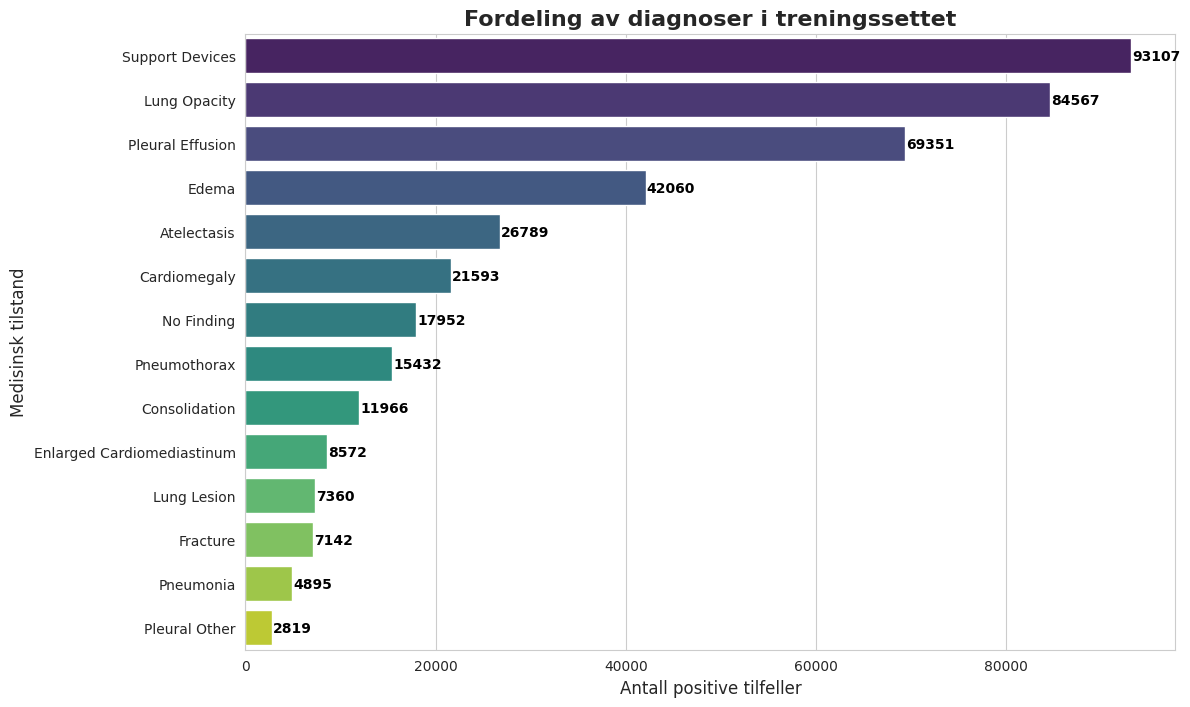

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = train_df[label_values].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')

plt.title("Fordeling av diagnoser i treningssettet", fontsize=16, fontweight='bold')
plt.xlabel("Antall positive tilfeller", fontsize=12)
plt.ylabel("Medisinsk tilstand", fontsize=12)


for i, v in enumerate(label_counts.values):
    plt.text(v + 100, i + .1, str(int(v)), color='black', fontweight='bold')

plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

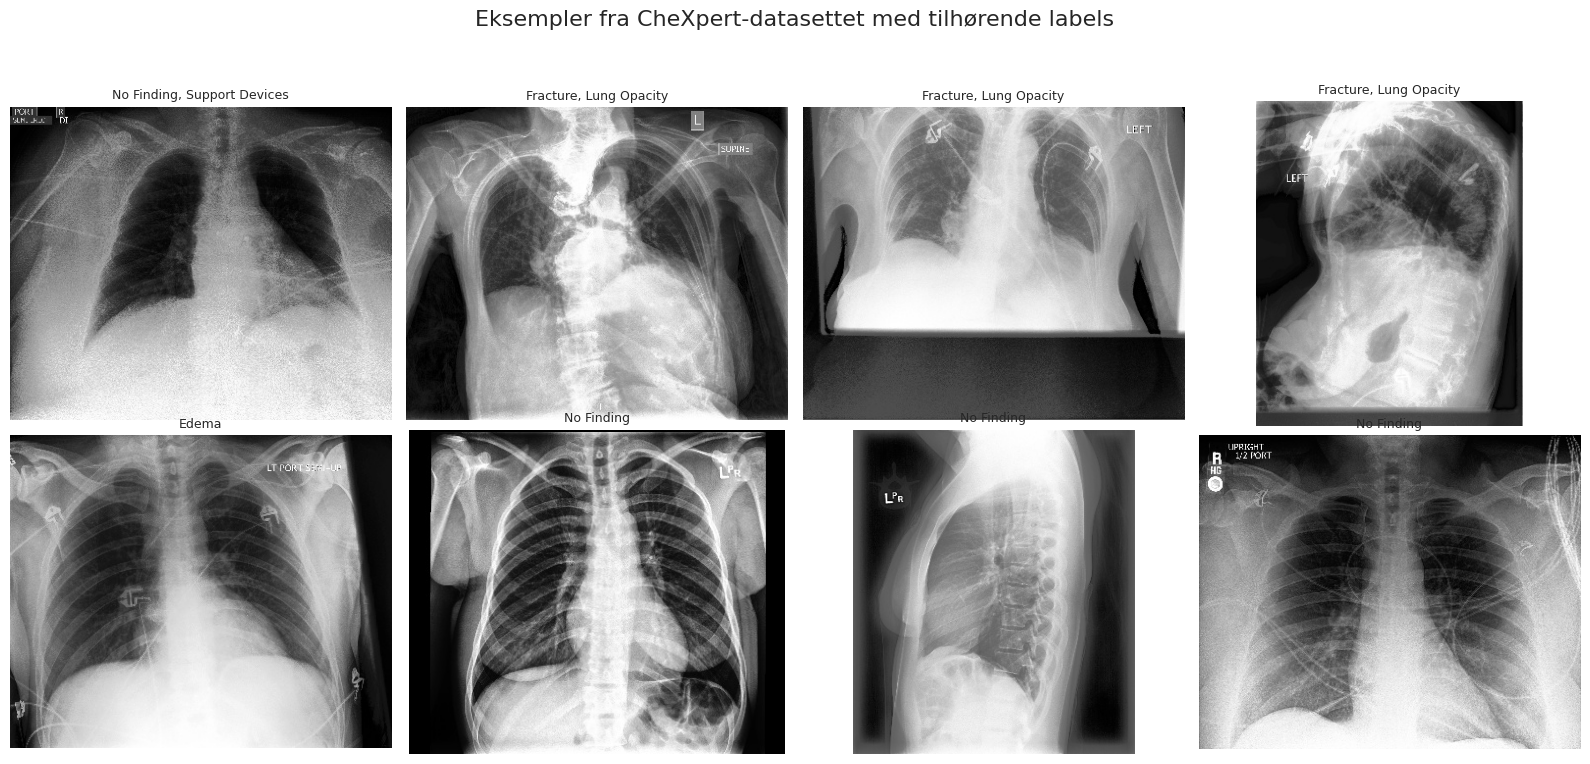

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flatten()):
    full_img_path = os.path.join(extract_path, train_df.iloc[i]['Path'])
    img = Image.open(full_img_path).convert("RGB")

    row = train_df.iloc[i]
    active_labels = [label for label in label_values if row[label] == 1]
    title = ", ".join(active_labels) if active_labels else "No Finding"

    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Eksempler fra CheXpert-datasettet med tilhørende labels", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('data_examples.png', dpi=300)
plt.show()

**DATA TRANSFORM**

Using data augmentation and resizing images to improve generalization and reduce overfitting.

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

**DATASET**




In [7]:
class CheXpertDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.label_columns = [
            'Atelectasis','Cardiomegaly','Consolidation','Edema',
            'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
            'Lung Opacity','No Finding','Pleural Effusion',
            'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        full_img_path = os.path.join(extract_path, row['Path'])
        img = Image.open(full_img_path).convert("RGB")

        labels = row[self.label_columns].values.astype(np.float32)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(labels)

**DATALOADER**

Dataloader are used to load data in batches

In [8]:
train_dataset = CheXpertDataset(train_df, train_transform)
valid_dataset = CheXpertDataset(valid_df, valid_transform)
test_dataset = CheXpertDataset(test_df, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**MODEL ARCHITECTURES**

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
model.classifier = nn.Linear(model.classifier.in_features, 14)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Model ready on:", device)
print("Model: DenseNet121")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 98.1MB/s]


Model ready on: cuda
Model: DenseNet121


**LOSS & OPTIMIZIER**

Binary Cross Entropy with logits is used for multi-label classification.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos_weight = torch.ones(14).to(device)

L_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(device)

cuda


In [11]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 14])


In [12]:
img, label = train_dataset[0]
print(img.shape, label.shape)

torch.Size([3, 224, 224]) torch.Size([14])


In [13]:
print(train_df.iloc[0]['Path'])
print(os.path.exists(os.path.join(extract_path, train_df.iloc[0]['Path'])))

train/patient00001/study1/view1_frontal.jpg
True


**Training of models**

In [14]:
print("Train size:", len(train_df))
print("Valid size:", len(valid_df))
print("Test size:", len(test_df))

Train size: 179132
Valid size: 22275
Test size: 22007


Models are trained using Adam optimizer with weight decay.

In [15]:
def train_model(model, epochs=5):
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.3, patience=2
    )

    train_losses = []
    val_losses = []

    best_f1 = 0

    for epoch in range(epochs):

        # 🔹 TRAIN
        model.train()
        running_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = L_func(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if i % 50 == 0:
                print(f"Epoch {epoch+1} Batch {i}/{len(train_loader)} Loss {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # 🔹 VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = L_func(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(valid_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        # 🔹 EVALUATION
        print("\nEvaluation:")
        f1, auc = evaluate(model, valid_loader)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")
        print(f"F1 Score:   {f1:.4f}")
        print(f"AUC:        {auc:.4f}")

        # 🔹 SAVE BEST MODEL
        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), "best_model_densenet121.pth")
            print("Beste DenseNet121-modell lagret!")

    return train_losses, val_losses

**EVALUATION**

Model performance is evaluated using Macro F1-score and ROC-AUC. Threshold tuning is applied to improve classification performance.

In [16]:
def get_preds(model,loader):
    model.eval()
    preds,targets=[],[]
    with torch.no_grad():
        for images,labels in loader:
            images=images.to(device)
            outputs=torch.sigmoid(model(images)).cpu().numpy()
            preds.append(outputs)
            targets.append(labels.numpy())
    return np.vstack(preds), np.vstack(targets)

In [17]:
def find_thresholds(preds,targets):
    thresholds=[]
    for i in range(14):
        best_t,best_f1=0.5,0
        for t in np.arange(0.1,0.9,0.05):
            f1=f1_score(targets[:,i], (preds[:,i]>t).astype(int))
            if f1>best_f1:
                best_f1, best_t = f1,t
        thresholds.append(best_t)
    return thresholds

In [18]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

def evaluate(model, loader):
    preds, targets = get_preds(model, loader)

    thresholds = []

    for i in range(14):
        best_t = 0.5
        best_f1 = 0

        for t in np.arange(0.1, 0.9, 0.05):
            pred_bin = (preds[:, i] > t).astype(int)
            f1 = f1_score(targets[:, i], pred_bin, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)

    preds_bin = np.zeros_like(preds)

    for i in range(14):
        preds_bin[:, i] = (preds[:, i] > thresholds[i]).astype(int)

    f1 = f1_score(targets, preds_bin, average="macro", zero_division=0)

    valid_auc = []
    for i in range(14):
        if len(np.unique(targets[:, i])) > 1:
            valid_auc.append(
                roc_auc_score(targets[:, i], preds[:, i])
            )

    auc = np.mean(valid_auc)

    print("Macro F1:", f1)
    print("Mean AUC:", auc)

    return f1, auc

RUN EFFICIENTNET

In [19]:
# RUN DENSENET121

# Trener modellen (lagrer beste automatisk)
train_losses, val_losses = train_model(model, epochs=5)

# Laster beste modell
model.load_state_dict(torch.load("best_model_densenet121.pth"))
model.to(device)

print("Beste DenseNet121-modell lastet ned!")

# Evaluerer beste modell
evaluate(model, test_loader)

# Lagrer final modell
torch.save(model.state_dict(), "densenet121_final.pth")
print("Final DenseNet121-modell lagret!")

Epoch 1 Batch 0/5598 Loss 0.7653
Epoch 1 Batch 50/5598 Loss 0.3656
Epoch 1 Batch 100/5598 Loss 0.3239
Epoch 1 Batch 150/5598 Loss 0.3756
Epoch 1 Batch 200/5598 Loss 0.3233
Epoch 1 Batch 250/5598 Loss 0.3572
Epoch 1 Batch 300/5598 Loss 0.3464
Epoch 1 Batch 350/5598 Loss 0.3365
Epoch 1 Batch 400/5598 Loss 0.3635
Epoch 1 Batch 450/5598 Loss 0.3297
Epoch 1 Batch 500/5598 Loss 0.3004
Epoch 1 Batch 550/5598 Loss 0.3016
Epoch 1 Batch 600/5598 Loss 0.3030
Epoch 1 Batch 650/5598 Loss 0.3275
Epoch 1 Batch 700/5598 Loss 0.3022
Epoch 1 Batch 750/5598 Loss 0.3345
Epoch 1 Batch 800/5598 Loss 0.3111
Epoch 1 Batch 850/5598 Loss 0.3321
Epoch 1 Batch 900/5598 Loss 0.3247
Epoch 1 Batch 950/5598 Loss 0.2720
Epoch 1 Batch 1000/5598 Loss 0.2863
Epoch 1 Batch 1050/5598 Loss 0.3210
Epoch 1 Batch 1100/5598 Loss 0.3888
Epoch 1 Batch 1150/5598 Loss 0.2835
Epoch 1 Batch 1200/5598 Loss 0.3180
Epoch 1 Batch 1250/5598 Loss 0.3610
Epoch 1 Batch 1300/5598 Loss 0.2834
Epoch 1 Batch 1350/5598 Loss 0.3486
Epoch 1 Batch 1

In [20]:

model.load_state_dict(torch.load("best_model_densenet121.pth"))

print("Henter prediksjoner for test-settet...")
test_preds, test_targets = get_preds(model, test_loader)

Henter prediksjoner for test-settet...


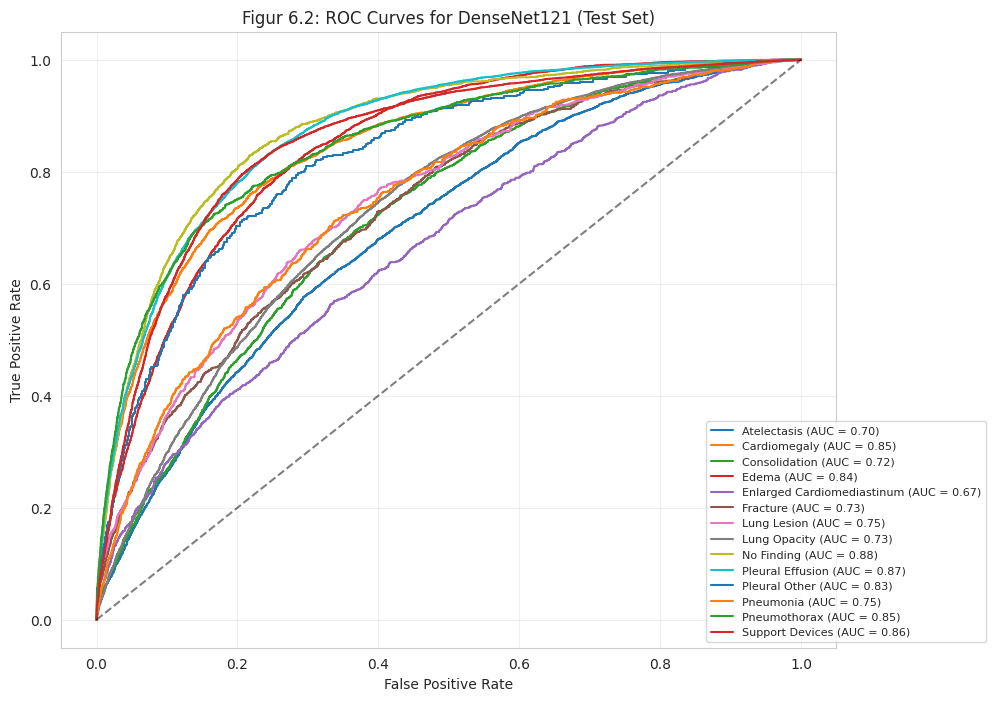

In [21]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for i in range(14):
    if len(np.unique(test_targets[:, i])) > 1:
        fpr, tpr, _ = roc_curve(test_targets[:, i], test_preds[:, i])
        roc_auc = auc(fpr, tpr)


        plt.plot(fpr, tpr, label=f"{label_values[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figur 6.2: ROC Curves for DenseNet121 (Test Set)")
plt.legend(loc="lower right", fontsize=8, bbox_to_anchor=(1.2, 0))
plt.grid(alpha=0.3)
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import f1_score

# 1. Hent alle sanne svar og modellens rå-tips (sannsynligheter)
model.eval()
all_preds = []
all_targets = []

print("Henter data fra valideringssettet...")
with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        # Vi regner ut sannsynligheter (0 til 1)
        outputs = torch.sigmoid(model(images))
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(labels.numpy())

# Samle alt til to store matriser
val_preds = np.vstack(all_preds)
val_targets = np.vstack(all_targets)

# 2. Finn den beste terskelen for hver av de 14 merkelappene
best_thresholds = []

print("Leter etter optimale terskler for hver sykdom...")
for i in range(14):
    thresholds = np.linspace(0, 1, 100) # Tester 0.01, 0.02 ... opp til 1.0
    best_f1 = 0
    best_thresh = 0.5

    for t in thresholds:
        # Vi tester hvordan F1-scoren blir med akkurat denne terskelen (t)
        current_f1 = f1_score(val_targets[:, i], (val_preds[:, i] > t).astype(int), zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = t

    best_thresholds.append(best_thresh)
    print(f"Ferdig med {label_values[i]}: Beste terskel = {best_thresh:.2f} (F1 = {best_f1:.4f})")

print("\nAlle terskler er klare i variabelen 'best_thresholds'!")

Henter data fra valideringssettet...
Leter etter optimale terskler for hver sykdom...
Ferdig med Atelectasis: Beste terskel = 0.16 (F1 = 0.3484)
Ferdig med Cardiomegaly: Beste terskel = 0.21 (F1 = 0.4973)
Ferdig med Consolidation: Beste terskel = 0.09 (F1 = 0.2057)
Ferdig med Edema: Beste terskel = 0.27 (F1 = 0.5944)
Ferdig med Enlarged Cardiomediastinum: Beste terskel = 0.08 (F1 = 0.1605)
Ferdig med Fracture: Beste terskel = 0.14 (F1 = 0.2174)
Ferdig med Lung Lesion: Beste terskel = 0.08 (F1 = 0.2009)
Ferdig med Lung Opacity: Beste terskel = 0.32 (F1 = 0.7019)
Ferdig med No Finding: Beste terskel = 0.23 (F1 = 0.5010)
Ferdig med Pleural Effusion: Beste terskel = 0.39 (F1 = 0.7445)
Ferdig med Pleural Other: Beste terskel = 0.09 (F1 = 0.1323)
Ferdig med Pneumonia: Beste terskel = 0.08 (F1 = 0.1585)
Ferdig med Pneumothorax: Beste terskel = 0.34 (F1 = 0.4897)
Ferdig med Support Devices: Beste terskel = 0.40 (F1 = 0.8054)

Alle terskler er klare i variabelen 'best_thresholds'!


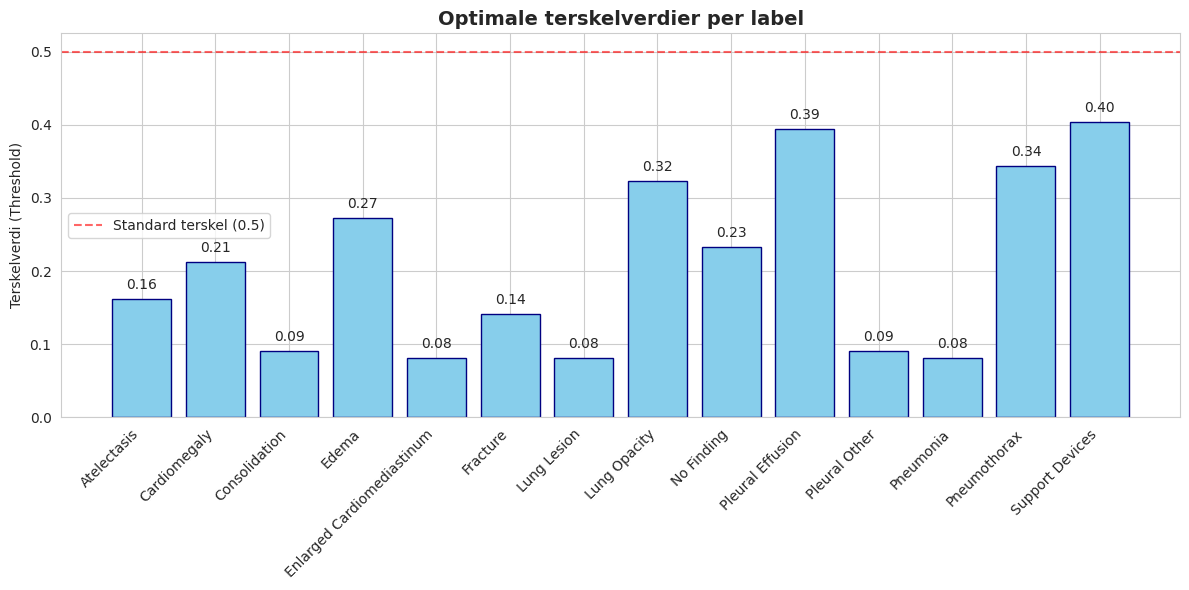

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")


bars = plt.bar(label_values, best_thresholds, color='skyblue', edgecolor='navy')


plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='Standard terskel (0.5)')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Terskelverdi (Threshold)')
plt.title('Optimale terskelverdier per label', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('optimal_thresholds.png', dpi=300)
plt.show()

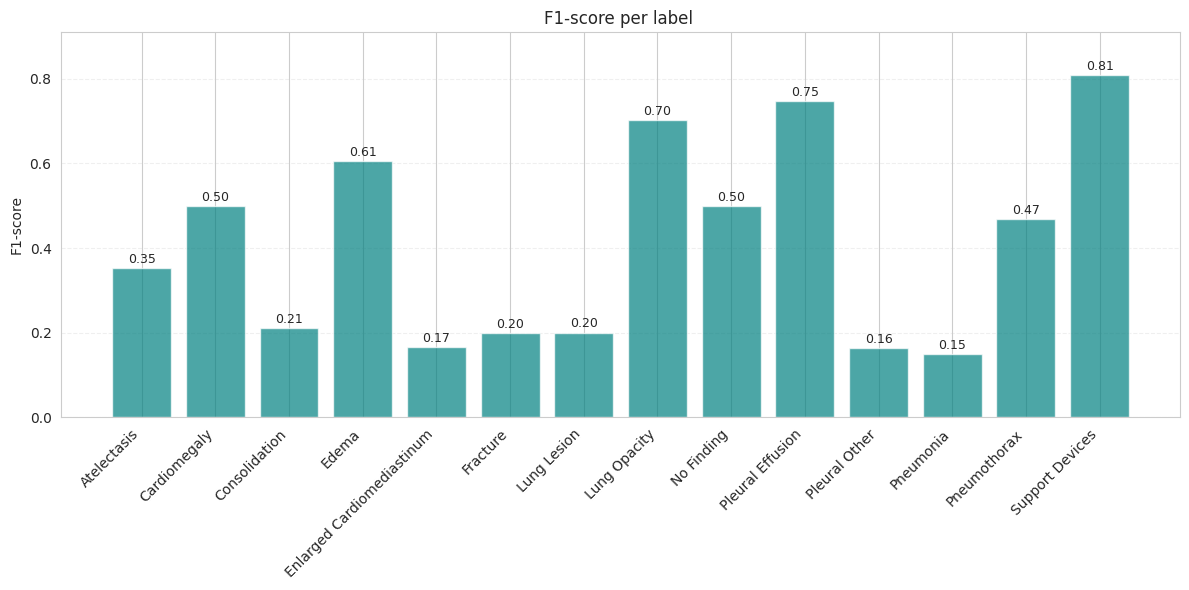

In [24]:
f1_scores = []

for i in range(14):

    threshold = best_thresholds[i]
    pred_bin = (test_preds[:, i] > threshold).astype(int)

    f1 = f1_score(test_targets[:, i], pred_bin, zero_division=0)
    f1_scores.append(f1)

plt.figure(figsize=(12, 6))
bars = plt.bar(label_values, f1_scores, color='teal', alpha=0.7)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.ylabel("F1-score")
plt.title("F1-score per label ")
plt.ylim(0, max(f1_scores) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

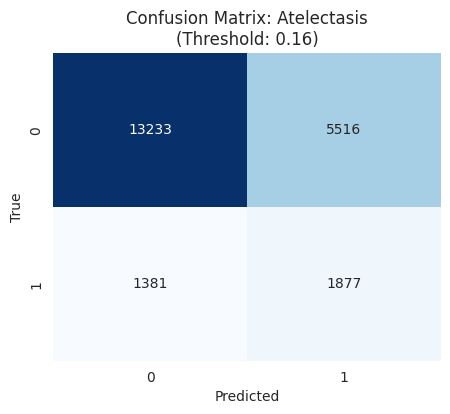

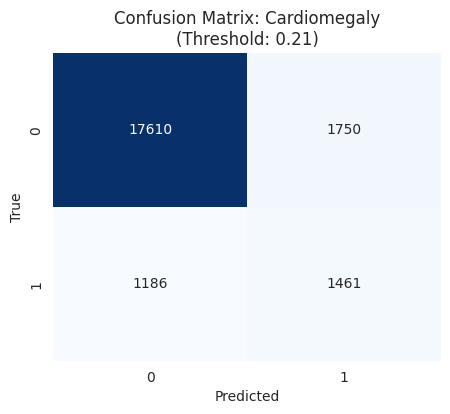

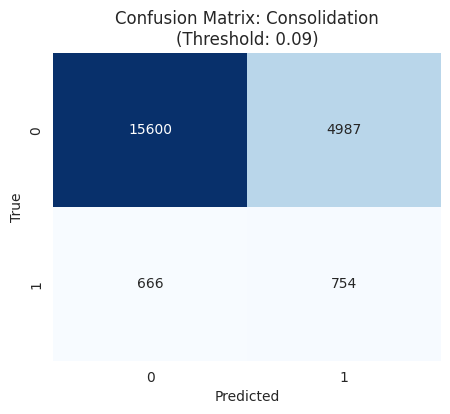

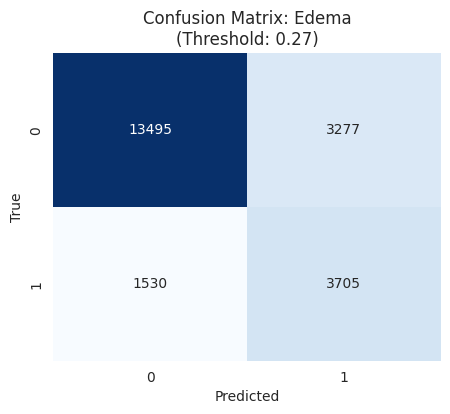

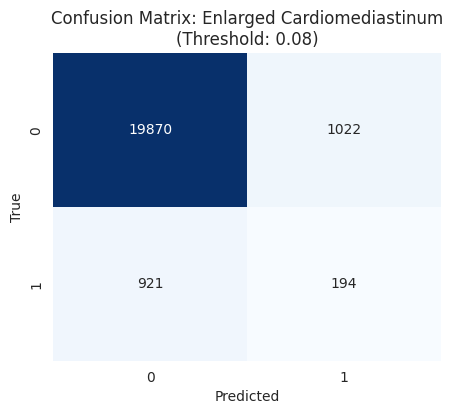

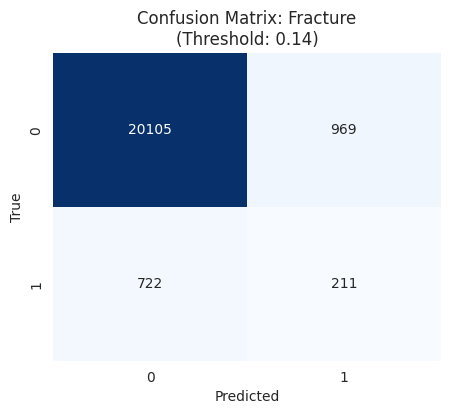

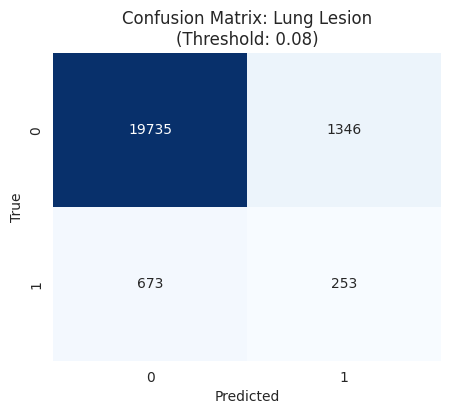

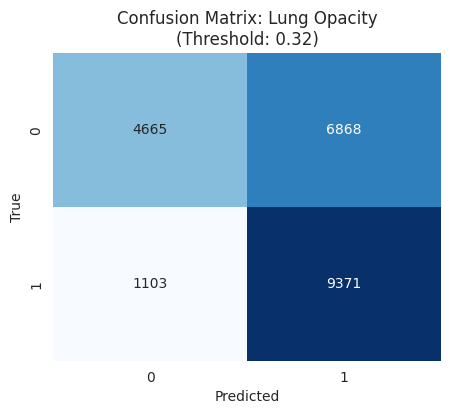

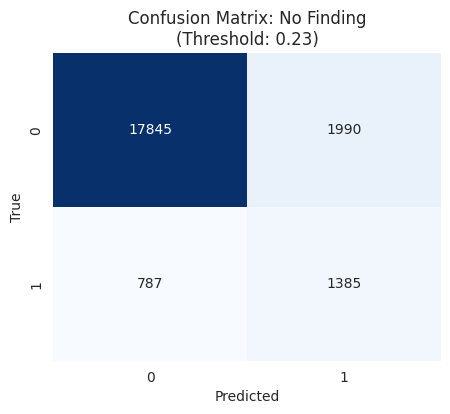

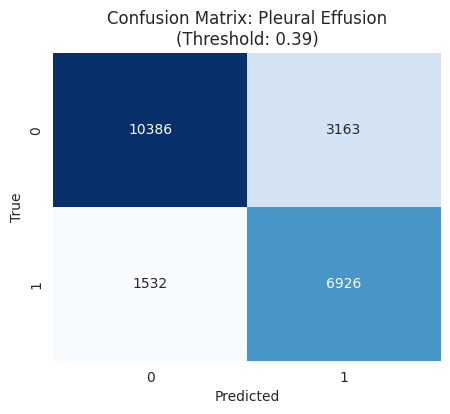

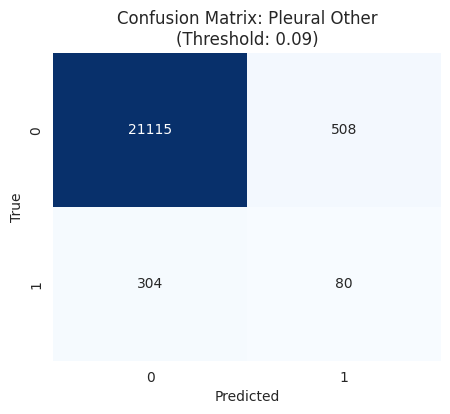

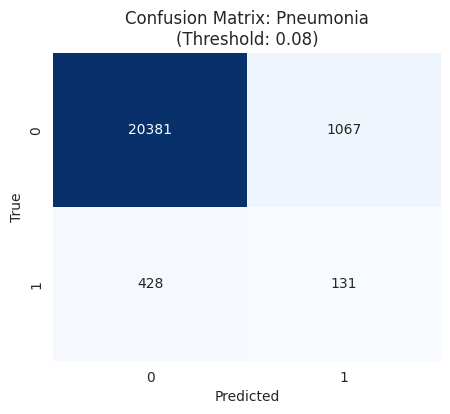

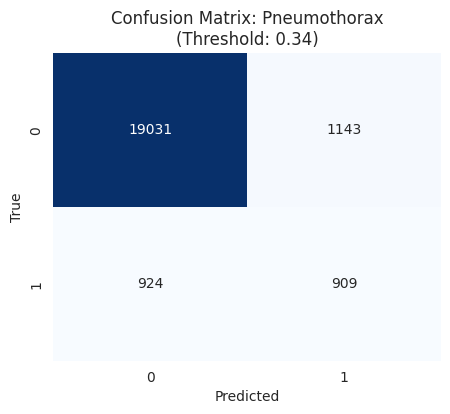

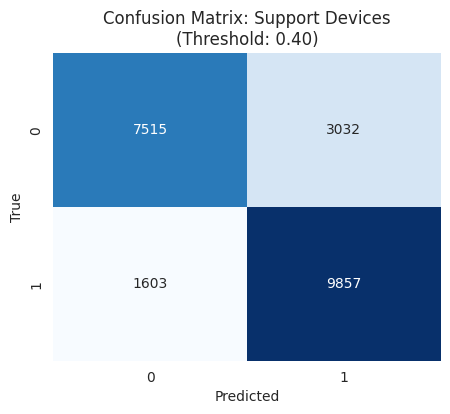

In [25]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
test_preds, test_targets = get_preds(model, test_loader)

for i in range(14):

    thresh = best_thresholds[i]
    test_preds_bin = (test_preds[:, i] > thresh).astype(int)

    cm = confusion_matrix(test_targets[:, i], test_preds_bin)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {label_values[i]}\n(Threshold: {thresh:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

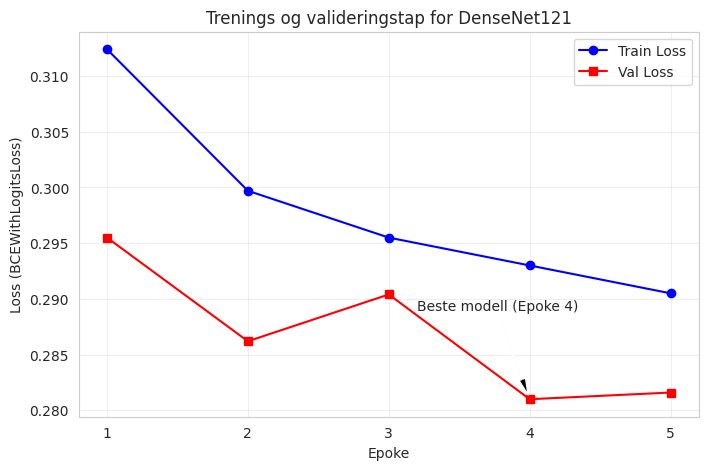

In [26]:
import matplotlib.pyplot as plt

train_losses = [0.3124, 0.2997, 0.2955, 0.2930, 0.2905]
val_losses   = [0.2955, 0.2862, 0.2904, 0.2810, 0.2816]
epochs = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'b-o', label="Train Loss")
plt.plot(epochs, val_losses, 'r-s', label="Val Loss")

# Marker den beste epoken basert på validation loss
plt.annotate('Beste modell (Epoke 4)', xy=(4, 0.2810), xytext=(3.2, 0.289),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.xlabel("Epoke")
plt.ylabel("Loss (BCEWithLogitsLoss)")
plt.title("Trenings og valideringstap for DenseNet121")
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
import cv2

In [31]:
import cv2

def generate_gradcam(model, image_tensor, target_layer, target_class):
    model.eval()

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output.detach())

        def save_gradient(grad):
            gradients.append(grad.detach())

        output.register_hook(save_gradient)

    hook = target_layer.register_forward_hook(forward_hook)

    output = model(image_tensor)
    model.zero_grad()

    score = output[0, target_class]
    score.backward()

    acts = activations[0][0].cpu().numpy()
    grads = gradients[0][0].cpu().numpy()

    weights = np.mean(grads, axis=(1, 2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)

    if np.max(cam) != 0:
        cam = cam / np.max(cam)

    cam = cv2.resize(cam, (224, 224))

    hook.remove()

    return cam

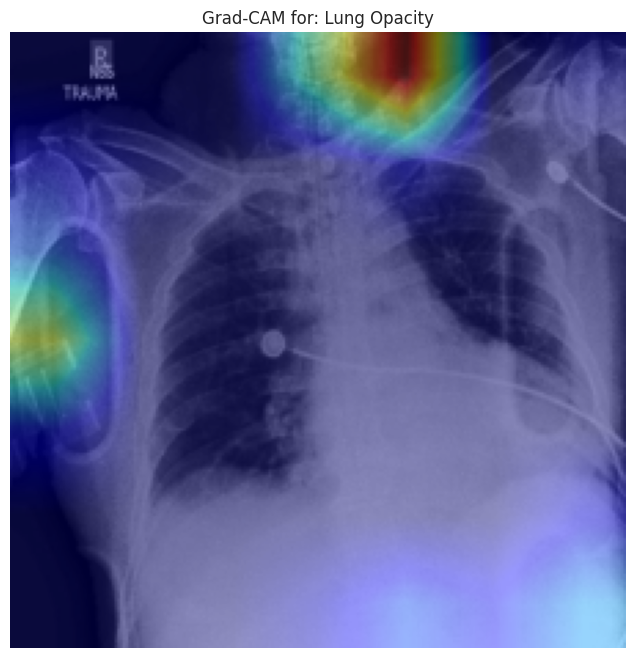

In [32]:
# Velg riktig target layer for EfficientNet-B0
target_layer = model.features.denseblock4.denselayer16.conv2

# Hent ett bilde fra test-settet
img, label = test_dataset[0]

input_tensor = img.unsqueeze(0).to(device)

# Kjør modellen og finn klassen med høyest score
output = model(input_tensor)
predicted_class = torch.argmax(output, dim=1).item()

# Generer Grad-CAM
cam = generate_gradcam(model, input_tensor, target_layer, predicted_class)

# Gjør bildet klart for plotting
img_np = img.permute(1, 2, 0).cpu().numpy()

# Av-normaliser bildet fordi du bruker Normalize i transforms
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

# Plot originalbilde + heatmap
plt.figure(figsize=(8, 8))
plt.imshow(img_np)
plt.imshow(cam, cmap='jet', alpha=0.4)
plt.title(f"Grad-CAM for: {label_values[predicted_class]}")
plt.axis('off')
plt.show()

In [34]:
torch.save(model.state_dict(), "/content/DenseNet_121_final.pth")
print("Modell lagret!")

Modell lagret!


In [35]:
from google.colab import files
files.download("/content/DenseNet_121_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
torch.save(model.state_dict(), "DenseNet_121_final.pth")
print("Riktig modell lagret!")

Riktig modell lagret!


In [37]:
from google.colab import files
files.download("DenseNet_121_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>